# 07 — Hyperparameter tuning (nested LOSO + Optuna)

**Phase 7 of the V3 rebuild.** Optuna Bayesian search on HGB hyperparameters under nested LOSO. The outer 14-subject LOSO is the unbiased performance estimator; the inner 5-fold StratifiedGroupKFold (over the 13 training subjects of each outer fold) selects hyperparameters. **Tuning on the outer test fold is forbidden by Hard Constraint #4 of the rebuild plan.**

**Locked from previous phases:**
- Features: 16 from Phase 5 ([selected_features.csv](../reports/05_feature_selection/selected_features.csv))
- Model: HistGradientBoosting (Phase 6 lock)
- Threshold: 0.5 (Phase 6 default)
- Phase 6 baseline: F1 = 0.931, recall = 0.911, min subj recall = 0.545

**Realistic expectation for tuning gain:** +0.005 to +0.020 F1. The Phase 6 finding that 86% of OOF predictions are confident (P<0.001 or P>0.999) caps how much hyperparameter tuning can move the needle — most windows aren't on the decision boundary.

**Search space** (HGB-specific):
| Hyperparameter | Range | Distribution | Current default |
|---|---|---|---|
| `learning_rate` | 0.005 – 0.5 | log-uniform | 0.05 |
| `max_iter` | 100 – 1000 | int | 300 |
| `max_depth` | 2 – 12 | int | 4 |
| `min_samples_leaf` | 5 – 100 | int | 20 |
| `l2_regularization` | 1e-6 – 10 | log-uniform | 0 |
| `max_leaf_nodes` | 10 – 200 | int | 31 |
| `max_features` | 0.3 – 1.0 | uniform | 1.0 |

**Side experiment in §6:** HGB + SVM-RBF probability-averaging ensemble. SVM-RBF was the best single model on S3 (0.727 vs HGB's 0.636). If averaging predictions from both models recovers S3 without hurting other subjects, that's a deployment-relevant ensemble worth keeping.

**Estimated runtime:** ~30-45 min for the nested-LOSO Optuna sweep + ~5 min for the rest.

## §1 — Setup, dependencies, sanity check

Optuna isn't in `requirements.txt`; the next cell will `pip install` it if missing. The Phase 4/5/6 sanity-check pattern (reload + HRV-validity assertions) is repeated here in case the cache has gone stale.

In [1]:
import os, sys, time, pickle, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'Updated_Extraction_V3').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
V3_DIR = REPO_ROOT / 'Updated_Extraction_V3'
sys.path.insert(0, str(V3_DIR))

from config_loader import load_config
import dataset_builder as db
import features as feats_mod
import eval_helpers as ev
import importlib
importlib.reload(feats_mod); importlib.reload(db); importlib.reload(ev)

# Optuna — install if missing
try:
    import optuna
    print(f'optuna {optuna.__version__} available')
except ImportError:
    print('Installing optuna...')
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '--quiet'])
    import optuna
    print(f'optuna {optuna.__version__} installed')

optuna.logging.set_verbosity(optuna.logging.WARNING)  # cut noise in cell outputs

CACHE_DIR = V3_DIR / 'output'
REPORTS_DIR = REPO_ROOT / 'reports' / '07_hyperparameter_tuning'
MODELS_DIR  = REPO_ROOT / 'models'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Reports dir: {REPORTS_DIR}')
print(f'Models dir:  {MODELS_DIR}')

Installing optuna...
optuna 4.8.0 installed
Reports dir: C:\Users\celliot\OneDrive - Milwaukee School of Engineering\Desktop\CurrentClasses\Senior_Design\Model_Dev\stress-detection-wearable\reports\07_hyperparameter_tuning
Models dir:  C:\Users\celliot\OneDrive - Milwaukee School of Engineering\Desktop\CurrentClasses\Senior_Design\Model_Dev\stress-detection-wearable\models


In [2]:
cfg = load_config()
RAW_CACHE = CACHE_DIR / f'dataset_W{cfg["windowing"]["window_size"]}_step{cfg["windowing"]["step_size"]}_raw.parquet'
df_raw = pd.read_parquet(RAW_CACHE)

# Sanity check
hrv_valid_frac = df_raw['hrv_valid'].mean()
hrv_mean_hr_valid = df_raw[df_raw['hrv_valid'] == 1]['hrv_mean_hr']
assert hrv_valid_frac > 0.5
assert 50 <= hrv_mean_hr_valid.mean() <= 100

# Locked 16 features from Phase 5
selected_path = REPO_ROOT / 'reports' / '05_feature_selection' / 'selected_features.csv'
LOCKED_16 = pd.read_csv(selected_path)['feature'].tolist()
missing = [f for f in LOCKED_16 if f not in df_raw.columns]
assert not missing, f'Missing features: {missing}'

X = df_raw[LOCKED_16].values
y = (df_raw['label'].values == 'stress').astype(int)
groups = df_raw['subject_id'].values
subjects = sorted(set(groups))

print(f'Dataset:    {df_raw.shape}')
print(f'Features:   {len(LOCKED_16)}')
print(f'Subjects:   {len(subjects)} ({subjects})')
print(f'Stress %:   {100*y.mean():.1f}%')
print(f'hrv_valid:  {100*hrv_valid_frac:.1f}%')

Dataset:    (691, 55)
Features:   16
Subjects:   14 (['S10', 'S11', 'S13', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9'])
Stress %:   22.3%
hrv_valid:  94.2%


In [3]:
# Phase 6 baseline (default HGB hyperparameters) — to confirm we're starting from the right number
baseline = ev.loso_evaluate(df_raw, LOCKED_16, model_factory=ev.hgb_factory())
print(f'Phase 6 baseline (default HGB on 16 features):')
print(f'  F1            = {baseline["mean_f1"]:.3f} ± {baseline["std_f1"]:.3f}')
print(f'  recall        = {baseline["mean_recall"]:.3f}')
print(f'  precision     = {baseline["mean_precision"]:.3f}')
print(f'  accuracy      = {baseline["mean_accuracy"]:.3f}')
print(f'  min subj recall = {baseline["min_subject_recall"]:.3f}')
print(f'  # subj < 0.5  = {baseline["n_subjects_recall_below_0_5"]}/14')
BASELINE_F1 = baseline['mean_f1']

Phase 6 baseline (default HGB on 16 features):
  F1            = 0.931 ± 0.094
  recall        = 0.911
  precision     = 0.972
  accuracy      = 0.973
  min subj recall = 0.545
  # subj < 0.5  = 0/14


## §2 — Optuna objective function and search space

The objective takes a `trial` and a fold's training data, runs 5-fold StratifiedGroupKFold over the training subjects, and returns the **mean F1 across inner folds** as the score Optuna maximizes.

Why StratifiedGroupKFold (not plain KFold or LOSO)?
- Plain KFold leaks subjects across train/val.
- LOSO inside the inner loop costs 13× more compute (13 inner folds × 25 trials × 14 outer folds = 4550 fits → ~4 hrs).
- StratifiedGroupKFold(5) puts ~2-3 subjects in each inner-val split, stratified by class balance, no subject leakage. Best balance of rigor and runtime.

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold, LeaveOneGroupOut
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

RANDOM_STATE = 42
INNER_K = 5      # inner StratifiedGroupKFold folds
N_TRIALS = 25    # Optuna trials per outer fold
OPTUNA_N_JOBS = 4  # parallel trials within each outer fold

def make_hgb(params):
    """Construct an HGB classifier from a hyperparameter dict."""
    return HistGradientBoostingClassifier(
        learning_rate=params['learning_rate'],
        max_iter=params['max_iter'],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        l2_regularization=params['l2_regularization'],
        max_leaf_nodes=params['max_leaf_nodes'],
        max_features=params['max_features'],
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )

def suggest_params(trial):
    """HGB hyperparameter search space — defended in docs/07_hyperparameter_tuning.md."""
    return {
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
        'max_iter':          trial.suggest_int('max_iter', 100, 1000),
        'max_depth':         trial.suggest_int('max_depth', 2, 12),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 5, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 10, 200),
        'max_features':      trial.suggest_float('max_features', 0.3, 1.0),
    }

def make_objective(X_train, y_train, groups_train, inner_k=INNER_K):
    """Returns an Optuna objective function for the given training set.
    The objective runs StratifiedGroupKFold over training subjects and
    returns mean F1 across inner folds."""
    sgkf = StratifiedGroupKFold(n_splits=inner_k, shuffle=True, random_state=RANDOM_STATE)
    inner_splits = list(sgkf.split(X_train, y_train, groups_train))
    def objective(trial):
        params = suggest_params(trial)
        f1s = []
        for tr_idx, val_idx in inner_splits:
            clf = make_hgb(params)
            clf.fit(X_train[tr_idx], y_train[tr_idx])
            pred = clf.predict(X_train[val_idx])
            f1s.append(f1_score(y_train[val_idx], pred, zero_division=0))
        return float(np.mean(f1s))
    return objective

print(f'Inner CV: StratifiedGroupKFold with {INNER_K} folds')
print(f'Trials per outer fold: {N_TRIALS}')
print(f'Optuna parallel jobs:  {OPTUNA_N_JOBS}')
print(f'Estimated total fits:  {14 * N_TRIALS * INNER_K} (~{14 * N_TRIALS * INNER_K * 3 / 60:.0f} min serial, ~{14 * N_TRIALS * INNER_K * 3 / 60 / OPTUNA_N_JOBS:.0f} min with n_jobs={OPTUNA_N_JOBS})')

Inner CV: StratifiedGroupKFold with 5 folds
Trials per outer fold: 25
Optuna parallel jobs:  4
Estimated total fits:  1750 (~88 min serial, ~22 min with n_jobs=4)


## §3 — Nested LOSO Optuna sweep

For each of the 14 outer LOSO folds:
1. Hold out one subject. Run Optuna on the 13 remaining subjects with 5-fold StratifiedGroupKFold inner CV.
2. Take the best hyperparameters from the inner study.
3. Re-fit HGB with those hyperparameters on **all 13 training subjects** (no inner split).
4. Predict on the held-out outer subject. Record predictions and the chosen hyperparameters.

After all 14 outer folds, we have unbiased LOSO predictions and a per-fold table of chosen hyperparameters.

In [5]:
logo = LeaveOneGroupOut()
outer_results = []          # one row per outer fold
outer_predictions = {}      # subject -> y_true, y_pred, y_proba
outer_studies = {}          # subject -> Optuna study (in case we want to interrogate later)

t_total = time.time()
for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    held_out = groups[test_idx[0]]
    t0 = time.time()

    # Inner Optuna study on training subjects only
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler,
                                study_name=f'hgb_outer_{held_out}')
    objective = make_objective(X[train_idx], y[train_idx], groups[train_idx])
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_N_JOBS, show_progress_bar=False)
    outer_studies[held_out] = study

    # Re-fit on all 13 training subjects with the chosen hyperparameters
    best_params = study.best_params
    clf = make_hgb(best_params)
    clf.fit(X[train_idx], y[train_idx])
    pred = clf.predict(X[test_idx])
    proba = clf.predict_proba(X[test_idx])[:, 1]

    yte = y[test_idx]
    fold_metrics = {
        'subject':   held_out,
        'n_test':    len(yte),
        'n_stress':  int(yte.sum()),
        'best_f1_inner': study.best_value,
        'outer_f1':  f1_score(yte, pred, zero_division=0),
        'outer_recall':    recall_score(yte, pred, zero_division=0),
        'outer_precision': precision_score(yte, pred, zero_division=0),
        'outer_accuracy':  accuracy_score(yte, pred),
        **{f'param_{k}': v for k, v in best_params.items()},
    }
    outer_results.append(fold_metrics)
    outer_predictions[held_out] = {'y_true': yte, 'y_pred': pred, 'y_proba': proba}

    elapsed = time.time() - t0
    print(f'  fold {fold_idx:>2d}/14 ({held_out}): inner F1={study.best_value:.3f}, '
          f'outer F1={fold_metrics["outer_f1"]:.3f}, recall={fold_metrics["outer_recall"]:.3f}  '
          f'({elapsed:.1f}s)')

outer_df = pd.DataFrame(outer_results)
outer_df.to_csv(REPORTS_DIR / 'nested_loso_per_fold.csv', index=False)
print(f'\nTotal nested-LOSO runtime: {(time.time()-t_total)/60:.1f} min')

  fold  1/14 (S10): inner F1=0.940, outer F1=0.857, recall=0.750  (131.2s)
  fold  2/14 (S11): inner F1=0.927, outer F1=0.917, recall=1.000  (84.9s)
  fold  3/14 (S13): inner F1=0.906, outer F1=0.880, recall=1.000  (125.7s)
  fold  4/14 (S15): inner F1=0.921, outer F1=1.000, recall=1.000  (94.3s)
  fold  5/14 (S16): inner F1=0.935, outer F1=0.952, recall=0.909  (146.9s)
  fold  6/14 (S17): inner F1=0.948, outer F1=0.917, recall=0.917  (199.8s)
  fold  7/14 (S2): inner F1=0.875, outer F1=0.889, recall=0.800  (95.0s)
  fold  8/14 (S3): inner F1=0.955, outer F1=0.737, recall=0.636  (145.8s)
  fold  9/14 (S4): inner F1=0.927, outer F1=1.000, recall=1.000  (123.8s)
  fold 10/14 (S5): inner F1=0.934, outer F1=1.000, recall=1.000  (135.8s)
  fold 11/14 (S6): inner F1=0.949, outer F1=0.917, recall=1.000  (106.6s)
  fold 12/14 (S7): inner F1=0.931, outer F1=1.000, recall=1.000  (197.1s)
  fold 13/14 (S8): inner F1=0.926, outer F1=1.000, recall=1.000  (98.6s)
  fold 14/14 (S9): inner F1=0.917, o

In [6]:
# Aggregate the unbiased nested-LOSO performance
tuned_mean_f1     = outer_df['outer_f1'].mean()
tuned_std_f1      = outer_df['outer_f1'].std()
tuned_mean_recall = outer_df['outer_recall'].mean()
tuned_min_recall  = outer_df['outer_recall'].min()
tuned_n_below     = int((outer_df['outer_recall'] < 0.5).sum())

print('=== Nested-LOSO unbiased performance estimate ===')
print(f'  Default HGB baseline (Phase 6):    F1 = {BASELINE_F1:.3f}')
print(f'  Nested-LOSO Optuna-tuned HGB:      F1 = {tuned_mean_f1:.3f} ± {tuned_std_f1:.3f}')
print(f'  Δ vs baseline:                     {tuned_mean_f1 - BASELINE_F1:+.3f}')
print()
print(f'  recall:        {tuned_mean_recall:.3f}')
print(f'  min subj recall: {tuned_min_recall:.3f}')
print(f'  # subj < 0.5:  {tuned_n_below}/14')

# Per-subject recall comparison vs baseline
psr_baseline = pd.Series(baseline['per_subject_recall']).sort_index()
psr_tuned    = outer_df.set_index('subject')['outer_recall'].sort_index()
psr_compare = pd.DataFrame({'baseline': psr_baseline, 'tuned': psr_tuned})
psr_compare['Δ'] = psr_compare['tuned'] - psr_compare['baseline']
print('\nPer-subject recall (baseline vs tuned):')
print(psr_compare.round(3).to_string())

=== Nested-LOSO unbiased performance estimate ===
  Default HGB baseline (Phase 6):    F1 = 0.931
  Nested-LOSO Optuna-tuned HGB:      F1 = 0.917 ± 0.085
  Δ vs baseline:                     -0.014

  recall:        0.903
  min subj recall: 0.636
  # subj < 0.5:  0/14

Per-subject recall (baseline vs tuned):
     baseline  tuned      Δ
S10     0.750  0.750  0.000
S11     1.000  1.000  0.000
S13     1.000  1.000  0.000
S15     1.000  1.000  0.000
S16     1.000  0.909 -0.091
S17     0.917  0.917  0.000
S2      0.900  0.800 -0.100
S3      0.636  0.636  0.000
S4      1.000  1.000  0.000
S5      1.000  1.000  0.000
S6      1.000  1.000  0.000
S7      1.000  1.000  0.000
S8      1.000  1.000  0.000
S9      0.545  0.636  0.091


## §4 — Hyperparameter stability across outer folds

Each outer fold picked its own "best" hyperparameters via the inner Optuna study. Stable hyperparameters (similar values picked across many outer folds) are the trustworthy ones; unstable hyperparameters tell us the model is relatively insensitive to them.

We aggregate the per-fold choices to surface (a) which hyperparameters consistently moved away from the defaults and (b) what the median/mode of the chosen values is — those are the numbers we ship in the final model.

In [7]:
param_cols = [c for c in outer_df.columns if c.startswith('param_')]
param_summary = outer_df[param_cols].agg(['median', 'mean', 'min', 'max', 'std']).T
param_summary.index = [c.replace('param_', '') for c in param_summary.index]

DEFAULTS = {
    'learning_rate': 0.05, 'max_iter': 300, 'max_depth': 4,
    'min_samples_leaf': 20, 'l2_regularization': 0.0,
    'max_leaf_nodes': 31, 'max_features': 1.0,
}
param_summary['default'] = pd.Series(DEFAULTS)
param_summary['median_vs_default'] = param_summary['median'] - param_summary['default']

param_summary.to_csv(REPORTS_DIR / 'hyperparameter_stability.csv')
print('Hyperparameter stability across 14 outer LOSO folds:')
print(param_summary[['default', 'median', 'mean', 'std', 'min', 'max']].round(4).to_string())

Hyperparameter stability across 14 outer LOSO folds:
                   default    median      mean       std       min       max
learning_rate         0.05    0.0920    0.1241    0.1337    0.0073    0.4920
max_iter            300.00  752.5000  682.7143  257.5752  120.0000  999.0000
max_depth             4.00    6.5000    6.9286    3.2455    2.0000   12.0000
min_samples_leaf     20.00    9.5000   13.0714    8.0141    5.0000   25.0000
l2_regularization     0.00    0.0612    0.8861    1.8692    0.0000    6.2291
max_leaf_nodes       31.00   92.0000   83.0714   49.8914   10.0000  178.0000
max_features          1.00    0.6000    0.5835    0.2063    0.3018    0.9996


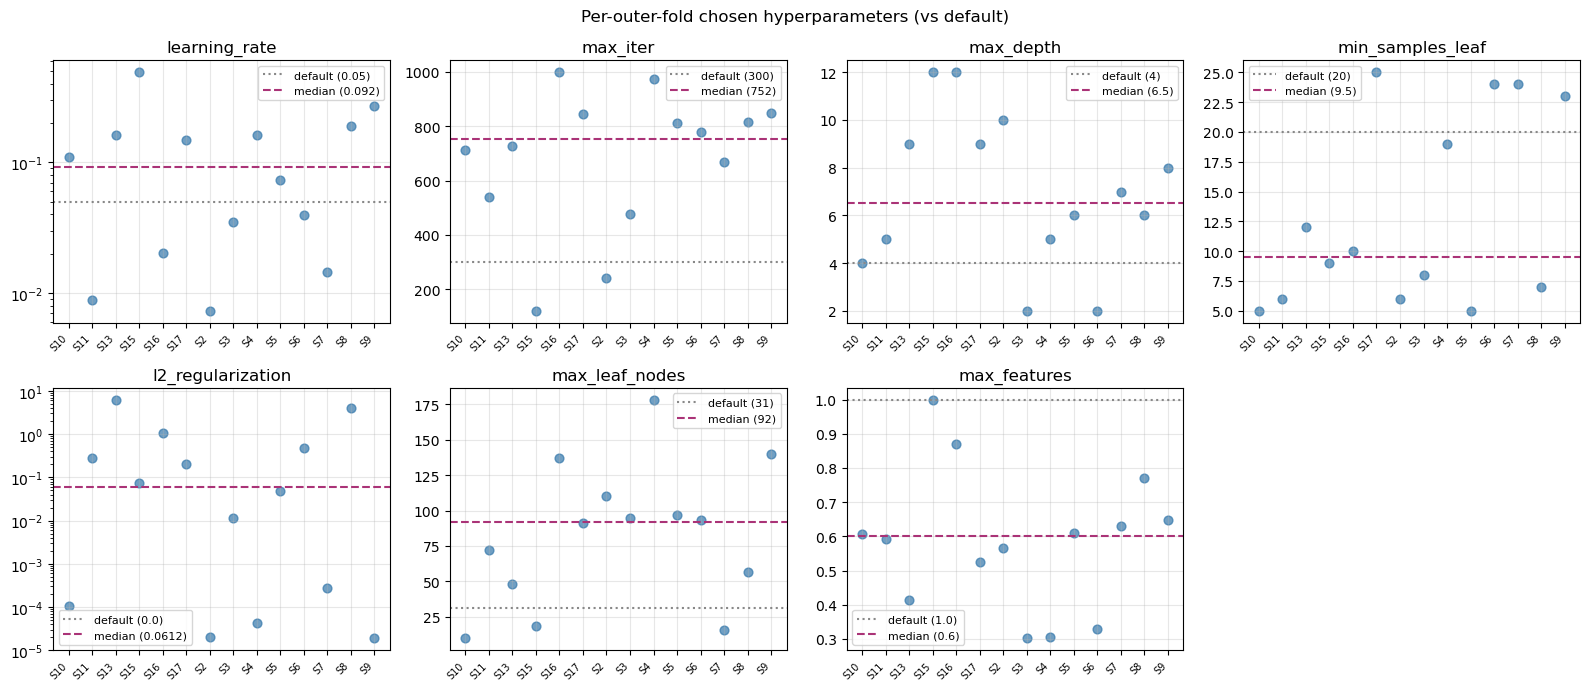

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, p in enumerate(param_cols):
    ax = axes[i]
    pname = p.replace('param_', '')
    vals = outer_df[p].values
    ax.scatter(range(len(vals)), vals, s=40, alpha=0.7, color='#37a')
    ax.axhline(DEFAULTS[pname], color='#888', linestyle=':', label=f'default ({DEFAULTS[pname]})')
    ax.axhline(np.median(vals), color='#a37', linestyle='--', label=f'median ({np.median(vals):.3g})')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(outer_df['subject'], rotation=45, ha='right', fontsize=7)
    ax.set_title(pname); ax.legend(fontsize=8)
    if pname in {'learning_rate', 'l2_regularization'}:
        ax.set_yscale('log')
    ax.grid(alpha=0.3)
for i in range(len(param_cols), len(axes)):
    axes[i].axis('off')
fig.suptitle('Per-outer-fold chosen hyperparameters (vs default)', fontsize=12)
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'hyperparameter_stability.png', dpi=120)
plt.show()

## §5 — Optuna search insights (one fold)

Pick one outer fold's Optuna study and visualize the search trajectory + parameter importance. Insights from one fold generalize because the search space is the same across folds — what matters is *which* parameters drove F1 changes, not the exact best values.

Visualizing search trajectory from outer fold S=S3
  inner F1 (best): 0.955
  best hyperparameters:
    learning_rate          = 0.0347
    max_iter               = 477
    max_depth              = 2
    min_samples_leaf       = 8
    l2_regularization      = 0.0113
    max_leaf_nodes         = 95
    max_features           = 0.3018


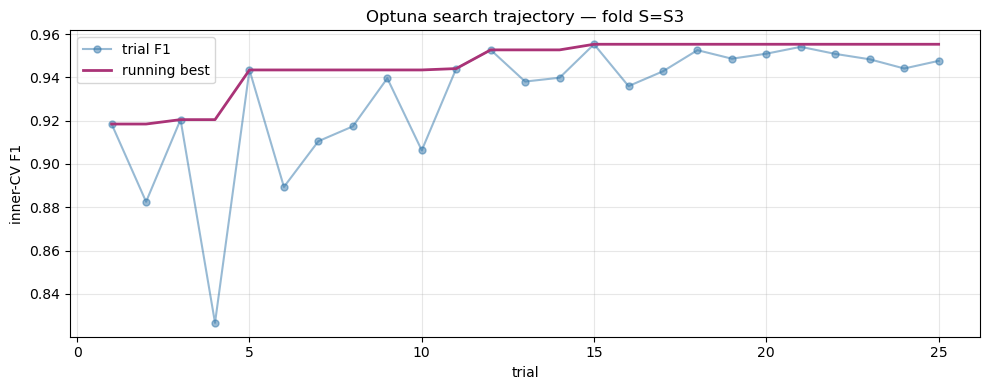

In [9]:
# Pick the fold with the best inner F1 (most informative search trajectory)
best_fold = outer_df.sort_values('best_f1_inner', ascending=False).iloc[0]['subject']
study_best = outer_studies[best_fold]

print(f'Visualizing search trajectory from outer fold S={best_fold}')
print(f'  inner F1 (best): {study_best.best_value:.3f}')
print(f'  best hyperparameters:')
for k, v in study_best.best_params.items():
    if isinstance(v, float):
        print(f'    {k:<22s} = {v:.4f}')
    else:
        print(f'    {k:<22s} = {v}')

# Search trajectory
fig, ax = plt.subplots(figsize=(10, 4))
trial_values = [t.value for t in study_best.trials if t.value is not None]
running_best = np.maximum.accumulate(trial_values)
ax.plot(range(1, len(trial_values)+1), trial_values, marker='o', alpha=0.5,
        markersize=5, label='trial F1', color='#37a')
ax.plot(range(1, len(running_best)+1), running_best, color='#a37', linewidth=2,
        label='running best')
ax.set_xlabel('trial'); ax.set_ylabel('inner-CV F1')
ax.set_title(f'Optuna search trajectory — fold S={best_fold}')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'optuna_trajectory.png', dpi=120)
plt.show()

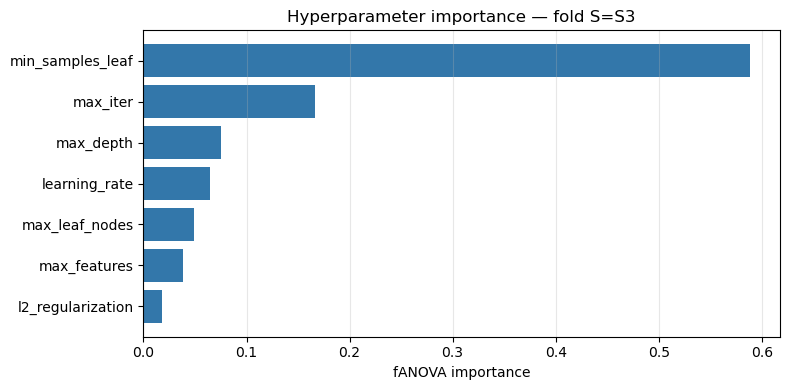


fANOVA importance (higher = bigger F1 effect):
            param  importance
 min_samples_leaf    0.588152
         max_iter    0.166311
        max_depth    0.075171
    learning_rate    0.064697
   max_leaf_nodes    0.049190
     max_features    0.038814
l2_regularization    0.017664


In [10]:
# Hyperparameter importance via Optuna's fANOVA
try:
    importances = optuna.importance.get_param_importances(study_best)
    imp_df = pd.DataFrame({'param': list(importances.keys()),
                           'importance': list(importances.values())})
    imp_df = imp_df.sort_values('importance', ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(imp_df['param'], imp_df['importance'], color='#37a')
    ax.set_xlabel('fANOVA importance')
    ax.set_title(f'Hyperparameter importance — fold S={best_fold}')
    ax.grid(alpha=0.3, axis='x')
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / 'param_importance.png', dpi=120)
    plt.show()
    print('\nfANOVA importance (higher = bigger F1 effect):')
    print(imp_df.sort_values('importance', ascending=False).to_string(index=False))
except Exception as e:
    print(f'fANOVA importance failed: {e}')

## §6 — Side experiment: HGB + SVM-RBF ensemble for S3

Phase 6 found SVM-RBF was the best model on S3 (recall 0.727 vs HGB's 0.636). Test whether averaging predicted probabilities from HGB + SVM-RBF recovers S3 without losing F1 elsewhere.

If F1 holds and S3 improves, the ensemble is a deployment-relevant finding worth keeping. If F1 drops or S3 doesn't improve, the experiment is logged and we stick with single-model HGB.

In [11]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def hgb_default():
    return HistGradientBoostingClassifier(
        max_iter=300, max_depth=4, learning_rate=0.05,
        class_weight='balanced', random_state=RANDOM_STATE)

def svm_default():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
                    probability=True, random_state=RANDOM_STATE)),
    ])

ensemble_results = []
for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    sid = groups[test_idx[0]]
    hgb = hgb_default(); hgb.fit(X[train_idx], y[train_idx])
    svm = svm_default(); svm.fit(X[train_idx], y[train_idx])
    p_hgb = hgb.predict_proba(X[test_idx])[:, 1]
    p_svm = svm.predict_proba(X[test_idx])[:, 1]
    p_avg = (p_hgb + p_svm) / 2
    pred = (p_avg >= 0.5).astype(int)
    yte = y[test_idx]
    ensemble_results.append({
        'subject': sid,
        'recall_hgb':      recall_score(yte, (p_hgb >= 0.5).astype(int), zero_division=0),
        'recall_svm':      recall_score(yte, (p_svm >= 0.5).astype(int), zero_division=0),
        'recall_ensemble': recall_score(yte, pred, zero_division=0),
        'f1_ensemble':     f1_score(yte, pred, zero_division=0),
    })
ens_df = pd.DataFrame(ensemble_results)

print(f'HGB + SVM-RBF probability ensemble:')
print(f'  ensemble F1 (LOSO mean): {ens_df["f1_ensemble"].mean():.3f} ± {ens_df["f1_ensemble"].std():.3f}')
print(f'  HGB alone F1:            {BASELINE_F1:.3f}')
print(f'  Δ:                       {ens_df["f1_ensemble"].mean() - BASELINE_F1:+.3f}')
print()
print(f'Per-subject recall comparison (focus on hard subjects):')
ens_df['Δ_vs_hgb'] = ens_df['recall_ensemble'] - ens_df['recall_hgb']
print(ens_df.set_index('subject').round(3).to_string())
ens_df.to_csv(REPORTS_DIR / 'ensemble_experiment.csv', index=False)

HGB + SVM-RBF probability ensemble:
  ensemble F1 (LOSO mean): 0.935 ± 0.089
  HGB alone F1:            0.931
  Δ:                       +0.004

Per-subject recall comparison (focus on hard subjects):
         recall_hgb  recall_svm  recall_ensemble  f1_ensemble  Δ_vs_hgb
subject                                                                
S10           0.750       0.667            0.750        0.857     0.000
S11           1.000       0.818            1.000        0.957     0.000
S13           1.000       0.636            1.000        0.917     0.000
S15           1.000       0.727            1.000        1.000     0.000
S16           1.000       0.909            1.000        1.000     0.000
S17           0.917       0.750            0.833        0.870    -0.083
S2            0.900       0.900            0.900        0.947     0.000
S3            0.636       0.636            0.727        0.842     0.091
S4            1.000       1.000            1.000        1.000     0.000
S5     

## §7 — Final shipping model

The nested-LOSO unbiased estimate from §3 tells us how the *tuned* HGB will generalize to a new subject. The actual *shipping* model needs hyperparameters that are reasonable across all 14 subjects, not just one outer fold.

We pick the **median** of each hyperparameter across the 14 outer folds and train HGB on the **full 14-subject dataset**. The median is robust to outlier folds and represents the "central tendency" of what the inner CV consistently chose.

Then we save: (a) the fitted final model, (b) the chosen hyperparameters as JSON, (c) the locked feature list.

In [12]:
# Median of each hyperparameter across the 14 outer folds
final_params = {}
for p in param_cols:
    pname = p.replace('param_', '')
    vals = outer_df[p].values
    if pname in {'max_iter', 'max_depth', 'min_samples_leaf', 'max_leaf_nodes'}:
        final_params[pname] = int(np.median(vals))
    else:
        final_params[pname] = float(np.median(vals))

print('Final shipping hyperparameters (median across 14 outer folds):')
for k, v in final_params.items():
    if isinstance(v, float):
        print(f'  {k:<22s} = {v:.4f}  (default {DEFAULTS[k]:.4g})')
    else:
        print(f'  {k:<22s} = {v}  (default {DEFAULTS[k]})')

# Sanity: confirm the median-params model achieves F1 close to the nested-LOSO estimate
def median_model_factory():
    return make_hgb(final_params)

median_check = ev.loso_evaluate(df_raw, LOCKED_16, model_factory=median_model_factory)
print(f'\nLOSO F1 with median hyperparameters (BIASED — same data for tuning and eval):')
print(f'  F1 = {median_check["mean_f1"]:.3f} ± {median_check["std_f1"]:.3f}')
print(f'  recall = {median_check["mean_recall"]:.3f}, min_subj = {median_check["min_subject_recall"]:.3f}')

# Train final model on ALL 14 subjects
final_model = make_hgb(final_params)
final_model.fit(X, y)

# Save artifacts
with open(MODELS_DIR / 'final_model.pkl', 'wb') as f:
    pickle.dump({
        'model': final_model,
        'feature_list': LOCKED_16,
        'threshold': 0.5,
        'hyperparameters': final_params,
        'nested_loso_f1':       float(tuned_mean_f1),
        'nested_loso_f1_std':   float(tuned_std_f1),
        'nested_loso_min_recall': float(tuned_min_recall),
        'baseline_f1': float(BASELINE_F1),
    }, f)

with open(MODELS_DIR / 'hyperparameters.json', 'w') as f:
    json.dump({
        'model_class': 'HistGradientBoostingClassifier',
        'hyperparameters': final_params,
        'feature_list': LOCKED_16,
        'threshold': 0.5,
        'random_state': RANDOM_STATE,
        'class_weight': 'balanced',
        'phase_6_baseline_f1': float(BASELINE_F1),
        'phase_7_nested_loso_f1': float(tuned_mean_f1),
        'phase_7_nested_loso_min_recall': float(tuned_min_recall),
    }, f, indent=2)

print(f'\nSaved final_model.pkl and hyperparameters.json to models/')

Final shipping hyperparameters (median across 14 outer folds):
  learning_rate          = 0.0920  (default 0.05)
  max_iter               = 752  (default 300)
  max_depth              = 6  (default 4)
  min_samples_leaf       = 9  (default 20)
  l2_regularization      = 0.0612  (default 0)
  max_leaf_nodes         = 92  (default 31)
  max_features           = 0.6000  (default 1)

LOSO F1 with median hyperparameters (BIASED — same data for tuning and eval):
  F1 = 0.922 ± 0.094
  recall = 0.898, min_subj = 0.545

Saved final_model.pkl and hyperparameters.json to models/


## §8 — Findings & decision

*Bullet points to look for in the cells above:*
- Did Optuna tuning improve F1 vs the default? By how much (Δ vs Phase 6 baseline)?
- Which hyperparameters moved most from their defaults? Which stayed near default (i.e., model was insensitive to them)?
- Per-subject: did tuning recover any hard subjects (S9, S3, S10), or just shuffle small gains across already-good subjects?
- Did the HGB+SVM ensemble recover S3? At what F1 cost (if any)?

After this notebook completes, the locked `final_model.pkl` + `hyperparameters.json` ship to Phase 8 (real-time simulator).

In [13]:
print('Phase 7 artifacts:')
print(f'  reports/07_hyperparameter_tuning/:')
for f in sorted(REPORTS_DIR.iterdir()):
    print(f'    - {f.name}')
print(f'  models/:')
for f in sorted(MODELS_DIR.iterdir()):
    print(f'    - {f.name}')
print()
print(f'Headline:')
print(f'  Phase 6 baseline F1:     {BASELINE_F1:.3f}')
print(f'  Phase 7 tuned F1 (unbiased nested LOSO): {tuned_mean_f1:.3f} ± {tuned_std_f1:.3f}  (Δ {tuned_mean_f1 - BASELINE_F1:+.3f})')
print(f'  Phase 7 ensemble F1:     {ens_df["f1_ensemble"].mean():.3f}  (Δ {ens_df["f1_ensemble"].mean() - BASELINE_F1:+.3f})')
print(f'  min subj recall:         {tuned_min_recall:.3f}  (was {baseline["min_subject_recall"]:.3f})')

Phase 7 artifacts:
  reports/07_hyperparameter_tuning/:
    - ensemble_experiment.csv
    - hyperparameter_stability.csv
    - hyperparameter_stability.png
    - nested_loso_per_fold.csv
    - optuna_trajectory.png
    - param_importance.png
  models/:
    - final_model.pkl
    - hyperparameters.json
    - README.md
    - saved_models

Headline:
  Phase 6 baseline F1:     0.931
  Phase 7 tuned F1 (unbiased nested LOSO): 0.917 ± 0.085  (Δ -0.014)
  Phase 7 ensemble F1:     0.935  (Δ +0.004)
  min subj recall:         0.636  (was 0.545)
